# YZ50 — Hafta 2: Backpropagation Çalışma Defteri

Bu notebook, Karpathy'nin micrograd yaklaşımını izleyerek automatic
differentiation ve backpropagation mekanizmasını scalar seviyesinde kurar.
Her görevde aynı düzen kullanılır:

```text
Kavram → Elle hesap → Kod → Çıktı → Yorum → Doğrulama
```

Notebook hücrelerinin çıktıları kaydedilir. Böylece GitHub üzerinde kodu
çalıştırmadan deney sonuçları, gradient tabloları ve loss eğrisi görülebilir.

## Büyük resim

Geçen hafta bir parametrenin türevini sayısal olarak, fonksiyonu birkaç kez
çalıştırarak hesapladık. Bu hafta bütün parametrelerin gradient'lerini tek bir
geriye geçişte hesaplayacağız:

```text
Forward pass
    ↓
Computation graph
    ↓
Final loss
    ↓
Backward pass: local derivative × üstten gelen gradient
    ↓
Bütün weight ve bias gradient'leri
    ↓
Gradient descent update
```

Önemli ayrım:

- **Backpropagation**, gradient'leri hesaplar.
- **Gradient descent**, hesaplanan gradient'lerle parametreleri günceller.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random
import sys

import matplotlib.pyplot as plt

from value import Value, numerical_derivative
from nn import Neuron, Layer, MLP
from train import TRAINING_INPUTS, TARGETS, train_model

print("Python:", sys.version.split()[0])

Python: 3.12.9


# Görev 1 — `Value` ve computation graph

## 1.1 Neden normal sayı yerine `Value`?

Normal bir `float` yalnızca sayısal sonucu saklar. Backpropagation yapabilmek
için bir sonucun:

- Sayısal değerini (`data`)
- Kendisini üreten node'ları (`_prev`)
- Hangi işlemle üretildiğini (`_op`)
- Final output'a göre türevini (`grad`)

saklamamız gerekir.

Doğrudan oluşturulan ve başka bir işlemden gelmeyen node'a **leaf node** denir.
Leaf node'un `_prev` kümesi ve `_op` bilgisi boştur.

In [2]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")

print("a:", a)
print("b:", b)
print("a leaf mi?:", len(a._prev) == 0 and a._op == "")

a: Value(data=2, grad=0)
b: Value(data=-3, grad=0)
a leaf mi?: True


### Çıktıyı nasıl yorumlamalıyım?

`data`, node'un forward pass değeridir. `grad` başlangıçta sıfırdır çünkü henüz
herhangi bir final output seçip backward pass çalıştırmadık. `a` ve `b` başka
işlemlerden oluşmadığı için computation graph'ın leaf node'larıdır.

## 1.2 Toplama ile ilk graph bağlantısı

Elle hesap:

```text
c = a + b = 2 + (-3) = -1
```

Beklenen graph:

```text
a ──┐
    + ──> c
b ──┘
```

Yeni `c`, yalnızca `-1` değerini değil, `a` ve `b` üzerinden `+` işlemiyle
üretildiğini de saklamalıdır.

In [3]:
c = a + b
c.label = "c"

print("c:", c)
print("operasyon:", c._op)
print("a önceki node mu?:", a in c._prev)
print("b önceki node mu?:", b in c._prev)

c: Value(data=-1, grad=0)
operasyon: +
a önceki node mu?: True
b önceki node mu?: True


### Çıktıyı nasıl yorumlamalıyım?

`c.data=-1`, forward hesabın doğru olduğunu gösterir. `_op='+'` ve iki `_prev`
bağlantısı ise graph'ın forward pass sırasında kurulduğunu kanıtlar. Artık
`c`den başlayıp kendisini meydana getiren `a` ve `b` node'larına dönebiliriz.

## 1.3 Çarpma ve birleşik ifade

Elle hesap:

```text
e = a × b = 2 × (-3) = -6
d = e + 10 = -6 + 10 = 4
```

```text
a ──┐
    * ──> e ──┐
b ──┘         + ──> d
10 ───────────┘
```

In [4]:
ten = Value(10.0, label="ten")
e = a * b
e.label = "e"
d = e + ten
d.label = "d"

for node in [a, b, e, ten, d]:
    previous_labels = sorted(child.label for child in node._prev)
    print(
        f"{node.label:>3} | data={node.data:>5.1f} | "
        f"op={node._op or 'leaf':>4} | prev={previous_labels}"
    )

  a | data=  2.0 | op=leaf | prev=[]
  b | data= -3.0 | op=leaf | prev=[]
  e | data= -6.0 | op=   * | prev=['a', 'b']
ten | data= 10.0 | op=leaf | prev=[]
  d | data=  4.0 | op=   + | prev=['e', 'ten']


### Görev 1 sonucu

Toplama ve çarpma yeni bir `Value` oluştururken ara sonuçları kaybetmez.
Final `d` node'undan `e` ve `ten`e, `e` üzerinden de `a` ve `b`ye geri
ulaşabiliriz. Bu bağlantılar daha sonra backward pass'in izleyeceği yolları
oluşturur.

Forward pass'in iki çıktısı vardır:

1. Hesabın sayısal sonucu
2. Bu hesabın computation graph'ı

# Görev 2 — Gradient'leri otomatikleştirmeden önce elle doldurmak

## 2A — Basit ifade

Kullanacağımız ifade:

```text
e = a × b
d = e + c
L = d × f
```

Değerler ve forward pass:

```text
a=2, b=-3, c=10, f=-2
e=-6, d=4, L=-8
```

Her node'un `grad` alanında şu türevi saklayacağız:

```text
node.grad = ∂L/∂node
```

In [5]:
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
f = Value(-2.0, label="f")
e = a * b; e.label = "e"
d = e + c; d.label = "d"
L = d * f; L.label = "L"

print(f"e={e.data}, d={d.data}, L={L.data}")

e=-6.0, d=4.0, L=-8.0


### Adım 1 — Backward başlangıcı

Her zaman final output'tan başlarız:

```text
∂L/∂L = 1
```

Bu, “L'yi çok küçük miktarda değiştirirsem L aynı miktarda değişir” demektir.

In [6]:
L.grad = 1.0

### Adım 2 — `L = d × f`

Çarpmanın local derivative'leri:

```text
∂L/∂d = f = -2
∂L/∂f = d = 4
```

Genel backward kuralında local derivative, üstten gelen `L.grad` ile çarpılır.
Bu ilk node'da `L.grad=1`dir.

In [7]:
d.grad = f.data * L.grad
f.grad = d.data * L.grad

### Adım 3 — `d = e + c`

Toplamanın iki local derivative'i de `1`dir. Chain rule:

```text
∂L/∂e = ∂L/∂d × ∂d/∂e = -2 × 1 = -2
∂L/∂c = ∂L/∂d × ∂d/∂c = -2 × 1 = -2
```

Toplama node'u üstten gelen gradient'i iki kola aynen yönlendirir.

In [8]:
e.grad = 1.0 * d.grad
c.grad = 1.0 * d.grad

### Adım 4 — `e = a × b`

```text
∂e/∂a = b = -3
∂e/∂b = a = 2
```

Chain rule:

```text
∂L/∂a = ∂L/∂e × ∂e/∂a = -2 × -3 = 6
∂L/∂b = ∂L/∂e × ∂e/∂b = -2 × 2 = -4
```

In [9]:
a.grad = b.data * e.grad
b.grad = a.data * e.grad

for node in [a, b, c, e, d, f, L]:
    print(f"{node.label:>2} | data={node.data:>5.1f} | grad={node.grad:>5.1f}")

 a | data=  2.0 | grad=  6.0
 b | data= -3.0 | grad= -4.0
 c | data= 10.0 | grad= -2.0
 e | data= -6.0 | grad= -2.0
 d | data=  4.0 | grad= -2.0
 f | data= -2.0 | grad=  4.0
 L | data= -8.0 | grad=  1.0


## Gradient'leri nasıl yorumlamalıyım?

- `a.grad=6`: `a`yı küçük bir `h` kadar artırırsak `L` yaklaşık `6h` artar.
- `b.grad=-4`: `b`yi artırırsak `L` yaklaşık dört kat hızlı azalır.
- `c.grad=-2`: `c`yi artırmak `L`yi azaltır.
- `f.grad=4`: `f`yi artırmak `L`yi artırır.

Gradient'in **işareti**, etkinin yönünü; **mutlak büyüklüğü**, hassasiyetin
gücünü gösterir. Bunlar yalnızca mevcut değerlerin yakınındaki yerel bilgilerdir.

Backpropagation'ın özeti:

```text
child.grad += local_derivative × output.grad
```

## 2B — Tek nöronda manuel backpropagation

İki girdili nöron:

```text
n = x1*w1 + x2*w2 + b
o = tanh(n)
```

Değerler:

```text
x1=2, x2=0, w1=-3, w2=1, b≈6.88137
n≈0.88137, o≈0.7071
```

`tanh` türevi:

```text
d tanh(n)/dn = 1 - tanh(n)^2 = 1 - o^2
```

In [10]:
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")
bias = Value(6.8813735870195432, label="b")

x1w1 = x1 * w1; x1w1.label = "x1w1"
x2w2 = x2 * w2; x2w2.label = "x2w2"
n = x1w1 + x2w2 + bias; n.label = "n"
o = n.tanh(); o.label = "o"

print(f"n={n.data:.8f}")
print(f"o=tanh(n)={o.data:.8f}")

n=0.88137359
o=tanh(n)=0.70710678


### Nöron gradient'lerini elle doldurmak

1. `o.grad = 1`
2. `n.grad = (1-o²) × o.grad = 0.5`
3. Toplamalar `0.5` gradient'ini `x1w1`, `x2w2` ve `bias`a taşır.
4. Çarpma kollarında diğer girdinin değeri local derivative olur.

Beklenen leaf gradient'leri:

```text
x1.grad = 0.5*w1 = -1.5
w1.grad = 0.5*x1 = 1.0
x2.grad = 0.5*w2 = 0.5
w2.grad = 0.5*x2 = 0.0
b.grad  = 0.5
```

`w2.grad=0` özellikle anlamlıdır: `x2=0` olduğu için bu örnekte `w2` ne kadar
değişirse değişsin `x2*w2` sıfır kalır ve output'u etkilemez.

In [11]:
o.grad = 1.0
n.grad = (1.0 - o.data**2) * o.grad
x1w1.grad = n.grad
x2w2.grad = n.grad
bias.grad = n.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

for node in [x1, w1, x2, w2, bias, n, o]:
    print(f"{node.label:>2} | data={node.data:>9.6f} | grad={node.grad:>9.6f}")

x1 | data= 2.000000 | grad=-1.500000
w1 | data=-3.000000 | grad= 1.000000
x2 | data= 0.000000 | grad= 0.500000
w2 | data= 1.000000 | grad= 0.000000
 b | data= 6.881374 | grad= 0.500000
 n | data= 0.881374 | grad= 0.500000
 o | data= 0.707107 | grad= 1.000000


### Görev 2 sonucu

Bir nöron da yalnızca toplama, çarpma ve `tanh` node'larından oluşan bir
matematiksel ifadedir. Elle backward yaparken her node'un yalnızca kendi local
derivative'ini bilmesi yeterlidir; chain rule bu küçük türevleri final output'a
kadar bağlar.

# Görev 3 — Otomatik `backward()`

Elle yaptığımız işlemi otomatikleştirmek için:

1. Output'tan erişilebilen bütün node'ları buluruz.
2. Çocuklar kendilerini kullanan node'lardan önce gelecek şekilde topological
   sıra oluştururuz.
3. Output gradient'ini `1` yaparız.
4. Sırayı ters çevirip her node'un `_backward()` fonksiyonunu çalıştırırız.

Ters sıra gereklidir çünkü bir node backward olmadan önce yukarıdaki bütün
yollardan gelen gradient katkılarının onda toplanmış olması gerekir.

In [12]:
a2 = Value(2.0, label="a")
b2 = Value(-3.0, label="b")
c2 = Value(10.0, label="c")
f2 = Value(-2.0, label="f")
L2 = (a2 * b2 + c2) * f2
L2.label = "L"

L2.backward()

print("Otomatik backward sonuçları:")
for node in [a2, b2, c2, f2, L2]:
    print(f"{node.label:>2} | data={node.data:>5.1f} | grad={node.grad:>5.1f}")

Otomatik backward sonuçları:
 a | data=  2.0 | grad=  6.0
 b | data= -3.0 | grad= -4.0
 c | data= 10.0 | grad= -2.0
 f | data= -2.0 | grad=  4.0
 L | data= -8.0 | grad=  1.0


### Manuel ve otomatik sonuç karşılaştırması

| Node | Manuel gradient | Otomatik gradient |
|---|---:|---:|
| a | 6 | 6 |
| b | -4 | -4 |
| c | -2 | -2 |
| f | 4 | 4 |

Eşleşme, topological traversal ve local backward kurallarının elle yaptığımız
chain rule hesabını doğru şekilde otomatikleştirdiğini gösterir.

## Gradient neden `+=` ile biriktirilir?

Bir node graph içinde birden fazla yerde kullanılabilir:

```text
y = x × x
```

`x`, output'u iki ayrı yol üzerinden etkiler. `x=3` için:

```text
dy/dx = x + x = 6
```

İki yolun katkısını toplamaz, gradient'in üzerine yazarsak yanlışlıkla `3`
buluruz. Bu nedenle local backward kurallarında `=` değil `+=` kullanılır.

In [13]:
reused = Value(3.0, label="x")
squared = reused * reused
squared.backward()

print("x=3 için x*x gradient'i:", reused.grad)
print("Beklenen analitik değer 2*x:", 2 * reused.data)

x=3 için x*x gradient'i: 6.0
Beklenen analitik değer 2*x: 6.0


### Görev 3 sonucu

`backward()` özel bir neural-network işlemi değildir. Herhangi bir scalar
computation graph üzerinde chain rule'u ters sırada uygular. Neural network'ler
bu genel matematiksel ifadelerin özel ve büyük bir sınıfıdır.

# Görev 4 — `tanh`ı parçalamak ve üç yöntemle doğrulamak

Hyperbolic tangent daha küçük operasyonlarla yazılabilir:

```text
tanh(x) = (e^(2x)-1) / (e^(2x)+1)
```

Bunun için `exp`, sabit `pow`, negatif alma, çıkarma ve bölme operasyonlarını
ekledik. Bir operasyonu tek node veya küçük node'ların birleşimi olarak yazmak
forward sonucu ve leaf gradient'lerini değiştirmemelidir.

In [14]:
input_value = 0.8813735870195432

atomic_x = Value(input_value, label="atomic_x")
atomic_output = atomic_x.tanh()
atomic_output.backward()

decomposed_x = Value(input_value, label="decomposed_x")
exp_2x = (2 * decomposed_x).exp()
decomposed_output = (exp_2x - 1) / (exp_2x + 1)
decomposed_output.backward()

print(f"Atomic tanh output:      {atomic_output.data:.12f}")
print(f"Parçalanmış output:      {decomposed_output.data:.12f}")
print(f"Atomic input gradient:   {atomic_x.grad:.12f}")
print(f"Parçalanmış gradient:    {decomposed_x.grad:.12f}")

Atomic tanh output:      0.707106781187
Parçalanmış output:      0.707106781187
Atomic input gradient:   0.500000000000
Parçalanmış gradient:    0.500000000000


### Neden sonuçlar aynı?

İki graph'ın iç node'ları farklıdır fakat temsil ettikleri matematiksel
fonksiyon aynıdır. Autograd açısından bir operasyonun ne kadar “atomik” olduğu
tasarım tercihidir. Gerekli olan yalnızca doğru forward hesap ve doğru local
derivative'tir.

## Üçlü gradient kontrolü

Aynı fonksiyonu üç yöntemle hesaplayacağız:

```text
f(x) = tanh(x² + 2x), x=0.5
```

1. Kendi `Value.backward()` motorumuz
2. Geçen haftaki merkezi fark numerical derivative
3. PyTorch autograd

Sayısal türev eğitim için verimsizdir; burada analitik backward uygulamamızı
kontrol eden bağımsız bir referans olarak kullanılır.

In [15]:
x_value = 0.5

# 1) Kendi autograd motorumuz
micro_x = Value(x_value)
micro_result = (micro_x * micro_x + 2 * micro_x).tanh()
micro_result.backward()

# 2) Numerical derivative
plain_function = lambda x: math.tanh(x*x + 2*x)
numeric_gradient = numerical_derivative(plain_function, x_value)

# 3) PyTorch autograd
try:
    import torch
    torch_x = torch.tensor(x_value, dtype=torch.float64, requires_grad=True)
    torch_result = torch.tanh(torch_x * torch_x + 2 * torch_x)
    torch_result.backward()
    torch_gradient = torch_x.grad.item()
except ImportError:
    torch_gradient = float("nan")
    print("PyTorch kurulu değil; üçüncü karşılaştırma çalıştırılamadı.")

print(f"Micrograd gradient: {micro_x.grad:.12f}")
print(f"Numerical gradient: {numeric_gradient:.12f}")
print(f"PyTorch gradient:   {torch_gradient:.12f}")
print(f"Micro-numeric fark: {abs(micro_x.grad-numeric_gradient):.3e}")
print(f"Micro-torch fark:   {abs(micro_x.grad-torch_gradient):.3e}")

Micrograd gradient: 0.841244598541
Numerical gradient: 0.841244598537
PyTorch gradient:   0.841244598541
Micro-numeric fark: 4.004e-12
Micro-torch fark:   0.000e+00


### Gradient kontrolünü nasıl yorumlamalıyım?

Üç sonucun floating-point toleransı içinde eşleşmesi şunları doğrular:

- Local derivative formüllerimiz doğru.
- Chain rule doğru yönde uygulanıyor.
- Topological backward sırası doğru.
- Birden fazla gradient yolu doğru toplanıyor.

Küçük son basamak farkları hata değil, floating-point temsilinin sonucudur.

# Görev 5 — `Neuron`, `Layer`, `MLP` ve eğitim

Yapı:

```text
Value → Neuron → Layer → MLP
```

Bir nöron:

```text
output = tanh(w₁x₁ + w₂x₂ + ... + b)
```

Bir layer aynı input'ları bağımsız parametrelere sahip birden fazla nörona
verir. MLP ise layer'ları sırayla birbirine bağlar.

In [16]:
random.seed(42)

neuron = Neuron(3)
layer = Layer(3, 4)
model = MLP(3, [4, 4, 1])
sample = [2.0, 3.0, -1.0]

print("Tek nöron output'u:", neuron(sample))
print("Dört nöronlu layer output'ları:", layer(sample))
print("MLP output'u:", model(sample))
print("3→4→4→1 MLP parametre sayısı:", len(model.parameters()))

Tek nöron output'u: Value(data=-0.98354, grad=0)
Dört nöronlu layer output'ları: [Value(data=0.376178, grad=0), Value(data=-0.988121, grad=0), Value(data=-0.999198, grad=0), Value(data=-0.975186, grad=0)]
MLP output'u: Value(data=0.355146, grad=0)
3→4→4→1 MLP parametre sayısı: 41


## Neden 41 parametre var?

```text
3→4 layer: 4 × (3 weight + 1 bias) = 16
4→4 layer: 4 × (4 weight + 1 bias) = 20
4→1 layer: 1 × (4 weight + 1 bias) = 5
Toplam: 16 + 20 + 5 = 41
```

Input verileri parametre değildir. Eğitim sırasında değiştirilen değerler
weight ve bias'lardır.

## Küçük veri kümesi ve loss

Hedefler `[-1, 1]` aralığındadır; output'ta `tanh` kullandığımız için bu aralık
uygundur. Loss, dört örneğin squared error toplamıdır:

```text
loss = Σ(prediction-target)²
```

Loss küçüldükçe tahminler hedeflere yaklaşır.

In [17]:
for inputs, target in zip(TRAINING_INPUTS, TARGETS):
    print("input:", inputs, "target:", target)

input: [2.0, 3.0, -1.0] target: 1.0
input: [3.0, -1.0, 0.5] target: -1.0
input: [0.5, 1.0, 1.0] target: -1.0
input: [1.0, 1.0, -1.0] target: 1.0


## Doğru training loop sırası

```text
1. Forward pass
2. Loss hesapla
3. zero_grad
4. backward
5. parameter.data -= learning_rate × parameter.grad
```

`zero_grad`, her yeni training step'inde eski gradient'leri temizler.
Backward kuralları aynı graph içindeki yolları toplayabilmek için `+=` kullanır;
bu nedenle farklı training step'leri arasında temizleme yapmazsak eski
gradient'ler yanlışlıkla birikir.

In [18]:
# zero_grad unutulduğunda gradient birikimini küçük örnekte görelim.
p = Value(2.0)
first_loss = p * p
first_loss.backward()
first_gradient = p.grad

second_loss = p * p
second_loss.backward()
accumulated_gradient = p.grad

p.grad = 0.0
third_loss = p * p
third_loss.backward()
reset_gradient = p.grad

print("İlk backward gradient'i:       ", first_gradient)
print("Sıfırlamadan ikinci backward:  ", accumulated_gradient)
print("Sıfırladıktan sonra backward:  ", reset_gradient)

İlk backward gradient'i:        4.0
Sıfırlamadan ikinci backward:   8.0
Sıfırladıktan sonra backward:   4.0


### Meşhur `zero_grad` bug'ı

`p²` için `p=2` noktasındaki doğru gradient `2p=4`tür. İkinci backward öncesi
gradient temizlenmezse önceki `4` ile yeni `4` toplanıp `8` olur. Basit bir
problem bu bug'a rağmen loss düşürebilir; “model çalışıyor” görünmesi kodun
doğru olduğuna kanıt değildir.

In [19]:
trained_model, loss_history, final_predictions = train_model(
    steps=50,
    learning_rate=0.05,
    seed=42,
    verbose=True,
)

print("\nİlk loss:", loss_history[0])
print("Son loss: ", loss_history[-1])
print("Hedefler: ", TARGETS)
print("Tahminler:", [round(value, 4) for value in final_predictions])

adım=00 loss=5.23051751
adım=01 loss=2.70468905
adım=02 loss=1.84602373
adım=03 loss=1.17748701
adım=04 loss=0.82172946
adım=09 loss=0.24605066
adım=19 loss=0.09031307
adım=29 loss=0.05236970
adım=39 loss=0.03606331
adım=49 loss=0.02716870

İlk loss: 5.230517512042235
Son loss:  0.0271687015723562
Hedefler:  [1.0, -1.0, -1.0, 1.0]
Tahminler: [0.9144, -0.9479, -0.8949, 0.9265]


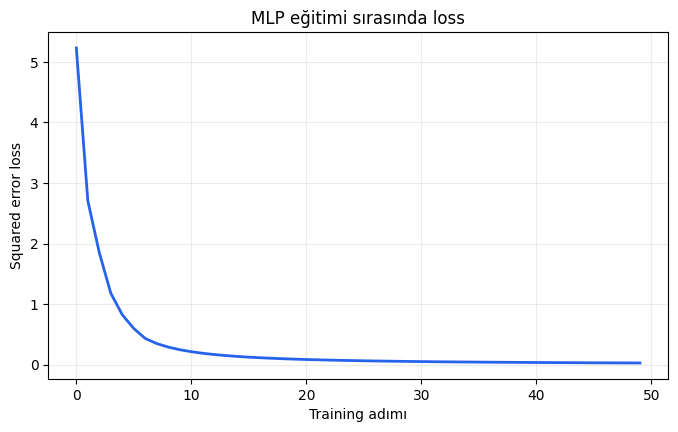

In [20]:
plt.figure(figsize=(8, 4.5))
plt.plot(loss_history, color="#2563eb", linewidth=2)
plt.title("MLP eğitimi sırasında loss")
plt.xlabel("Training adımı")
plt.ylabel("Squared error loss")
plt.grid(alpha=0.25)
plt.show()

### Eğitim çıktısını nasıl yorumlamalıyım?

- İlk loss, rastgele parametrelerin tahmin hatasıdır.
- Her backward pass 41 parametrenin gradient'ini hesaplar.
- Gradient descent bütün parametreleri loss'un azalış yönünde günceller.
- Loss eğrisinin düşmesi optimizasyonun çalıştığını gösterir.
- Son tahminlerin `[1, -1, -1, 1]` hedeflerine yaklaşması loss düşüşünün model
  davranışına yansıdığını gösterir.

Learning rate yalnızca yerel gradient bilgisine dayanarak ne kadar büyük adım
atılacağını belirler. Çok küçük değer yavaş, çok büyük değer kararsız eğitim
oluşturabilir.

# Hafta 2 — Genel sonuç

Bu çalışmada:

1. Matematiksel işlemler yapılırken computation graph kurdum.
2. Basit ifade ve tek nöronda gradient'leri elle hesapladım.
3. Chain rule'u ters topological sırada uygulayan `backward()` yazdım.
4. Aynı node'un birden fazla kullanıldığı durumda gradient'leri topladım.
5. `tanh`ı `exp`, `pow`, çıkarma ve bölme işlemlerine ayırdım.
6. Gradient'leri kendi backward motorum, numerical derivative ve PyTorch ile
   karşılaştırdım.
7. `Neuron`, `Layer` ve `MLP` sınıflarını kurup 41 parametreli ağı eğittim.
8. Her training adımında gradient'lerin neden sıfırlanması gerektiğini gördüm.

## Tek cümlelik zihinsel model

> Backpropagation, final loss'tan başlayarak her node'un local derivative'ini
> üstten gelen gradient ile çarpar, birden fazla yolun katkılarını toplar ve
> bütün parametrelerin loss üzerindeki etkisini tek bir geriye geçişte hesaplar.

## Language model bağlantısı

Büyük language model'ler farklı mimari, tensor işlemleri ve cross-entropy loss
kullanır. Ancak temel eğitim döngüsü aynıdır:

```text
token'lar → forward → next-token loss → backward → optimizer update
```

Micrograd scalar seviyede aynı mekanizmanın görünür ve anlaşılabilir halidir.